# Task 4 — Email Spam Detection with Machine Learning

Objective: classify ham vs spam using NLP, TF-IDF and two classifiers.

(5572, 2)


,label,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


,Count,Percentage
label,,
ham,4825,86.59
spam,747,13.41


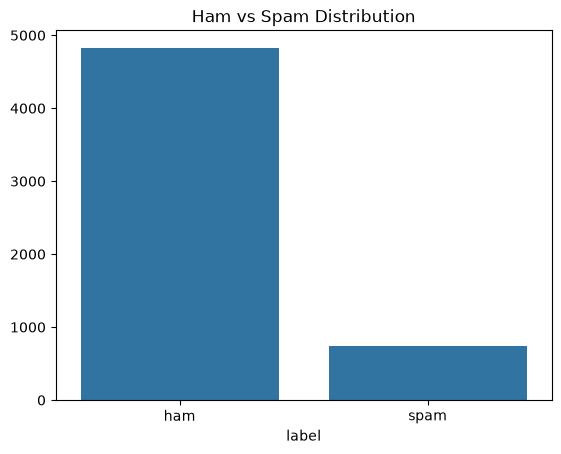

In [1]:
import re,numpy as np,pandas as pd,matplotlib.pyplot as plt,seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer,ENGLISH_STOP_WORDS
from sklearn.pipeline import Pipeline
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,confusion_matrix,classification_report
df=pd.read_csv("SMSSpamCollection",sep="\t",header=None,names=["label","text"],encoding="utf-8"); print(df.shape); display(df.head()); counts=df.label.value_counts(); display(pd.DataFrame({"Count":counts,"Percentage":(counts/len(df)*100).round(2)})); sns.barplot(x=counts.index,y=counts.values); plt.title("Ham vs Spam Distribution"); plt.show()

## 1. Text preprocessing

In [2]:
stop=set(ENGLISH_STOP_WORDS)
def clean(t):
 t=re.sub(r"[^a-z\s]"," ",t.lower()); return " ".join(w for w in t.split() if w not in stop)
df["clean_text"]=df.text.astype(str).apply(clean); display(df.head(10))

,label,text,clean_text
0,ham,"Go until jurong point, crazy.. Available only ...",jurong point crazy available bugis n great wor...
1,ham,Ok lar... Joking wif u oni...,ok lar joking wif u oni
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,free entry wkly comp win fa cup final tkts st ...
3,ham,U dun say so early hor... U c already then say...,u dun say early hor u c say
4,ham,"Nah I don't think he goes to usf, he lives aro...",nah don t think goes usf lives
5,spam,FreeMsg Hey there darling it's been 3 week's n...,freemsg hey darling s week s word d like fun t...
6,ham,Even my brother is not like to speak with me. ...,brother like speak treat like aids patent
7,ham,As per your request 'Melle Melle (Oru Minnamin...,request melle melle oru minnaminunginte nurung...
8,spam,WINNER!! As a valued network customer you have...,winner valued network customer selected receiv...
9,spam,Had your mobile 11 months or more? U R entitle...,mobile months u r entitled update latest colou...


## 2. TF-IDF explanation
TF-IDF combines term frequency with inverse document frequency. A word receives higher weight when it is frequent in a message but not common across the entire collection. This converts text into numeric features suitable for classical machine-learning classifiers.

In [3]:
Xtr,Xte,ytr,yte=train_test_split(df.clean_text,df.label,test_size=.20,random_state=42,stratify=df.label)
models={"Multinomial Naive Bayes":Pipeline([("tfidf",TfidfVectorizer(ngram_range=(1,2),min_df=2,sublinear_tf=True)),("model",MultinomialNB())]),"Logistic Regression":Pipeline([("tfidf",TfidfVectorizer(ngram_range=(1,2),min_df=2,sublinear_tf=True)),("model",LogisticRegression(max_iter=1000,random_state=42))])}; results={}
for n,m in models.items():
 m.fit(Xtr,ytr); p=m.predict(Xte); results[n]={"model":m,"pred":p,"Accuracy":accuracy_score(yte,p),"Precision":precision_score(yte,p,pos_label="spam"),"Recall":recall_score(yte,p,pos_label="spam"),"F1":f1_score(yte,p,pos_label="spam")}
metrics=pd.DataFrame(results).T.sort_values("F1",ascending=False); display(metrics.round(4))

,model,pred,Accuracy,Precision,Recall,F1
Multinomial Naive Bayes,"(TfidfVectorizer(min_df=2, ngram_range=(1, 2),...","[ham, ham, ham, spam, ham, ham, ham, ham, ham,...",0.970404,1.0,0.778523,0.875472
Logistic Regression,"(TfidfVectorizer(min_df=2, ngram_range=(1, 2),...","[ham, ham, ham, spam, ham, ham, ham, ham, ham,...",0.969507,1.0,0.771812,0.871212


## 3. Evaluation

============================================================ Multinomial Naive Bayes
              precision    recall  f1-score   support

         ham     0.9670    1.0000    0.9832       966
        spam     1.0000    0.7785    0.8755       149

    accuracy                         0.9704      1115
   macro avg     0.9835    0.8893    0.9293      1115
weighted avg     0.9714    0.9704    0.9688      1115



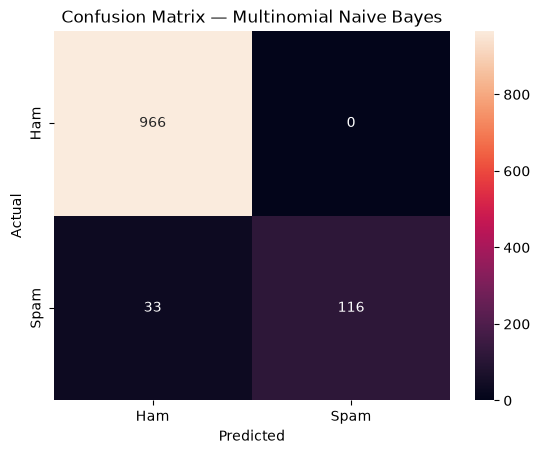

============================================================ Logistic Regression
              precision    recall  f1-score   support

         ham     0.9660    1.0000    0.9827       966
        spam     1.0000    0.7718    0.8712       149

    accuracy                         0.9695      1115
   macro avg     0.9830    0.8859    0.9270      1115
weighted avg     0.9705    0.9695    0.9678      1115



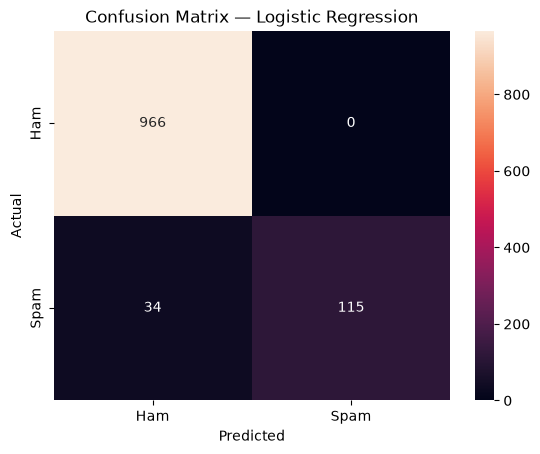

In [4]:
for n,r in results.items():
 print("="*60,n); print(classification_report(yte,r["pred"],digits=4)); cm=confusion_matrix(yte,r["pred"],labels=["ham","spam"]); sns.heatmap(cm,annot=True,fmt="d",xticklabels=["Ham","Spam"],yticklabels=["Ham","Spam"]); plt.title(f"Confusion Matrix — {n}"); plt.xlabel("Predicted"); plt.ylabel("Actual"); plt.show()

## 4. Why recall matters
Recall is important because a false negative is a real spam message that the system fails to catch. Missing spam can expose users to scams, phishing and malicious links. Precision still matters because excessive false positives can hide legitimate messages. F1 balances both.

## 5. Best model

In [5]:
best=metrics.index[0]; print("Best-performing model by spam F1-score:",best); display(metrics.loc[best].to_frame("Score"))

Best-performing model by spam F1-score: Multinomial Naive Bayes


,Score
model,"(TfidfVectorizer(min_df=2, ngram_range=(1, 2),..."
pred,"[ham, ham, ham, spam, ham, ham, ham, ham, ham,..."
Accuracy,0.970404
Precision,1.0
Recall,0.778523
F1,0.875472


## 6. Bonus WordClouds

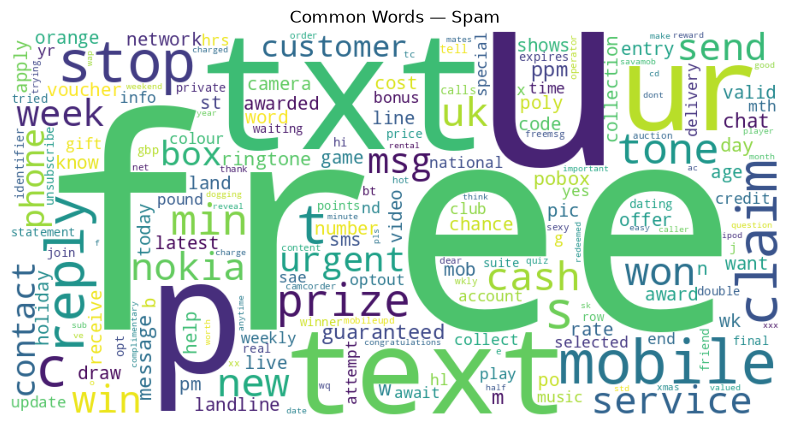

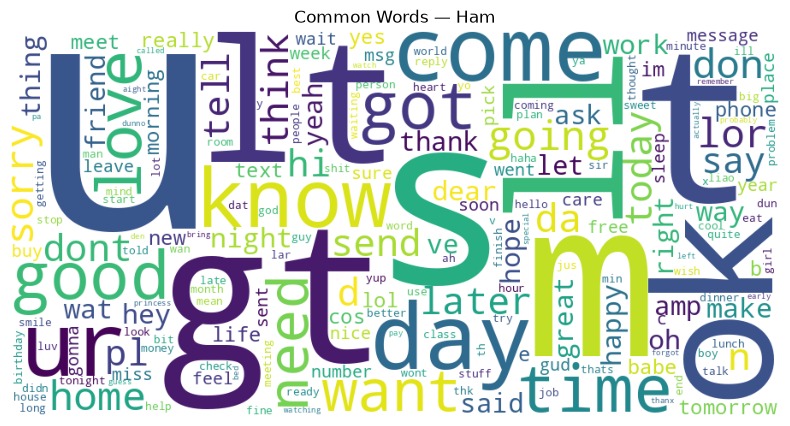

In [6]:
try:
 from wordcloud import WordCloud
 for label in ["spam","ham"]:
  text=" ".join(df.loc[df.label==label,"clean_text"]); wc=WordCloud(width=900,height=450,background_color="white",collocations=False).generate(text); plt.figure(figsize=(12,5)); plt.imshow(wc); plt.axis("off"); plt.title(f"Common Words — {label.title()}"); plt.show()
except ImportError: print("Install wordcloud from requirements.txt to run this bonus cell.")

## Final conclusion
The notebook covers class distribution, preprocessing, TF-IDF, two classifiers, all requested evaluation metrics, confusion matrices, recall explanation and the optional WordCloud.